In [1]:
!pip install imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Evaluation libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from collections import Counter

In [3]:
# Loading the clean data 
df = pd.read_csv('../../data/processed/dropout/oula_preprocessed.csv')

# Separate the Features (X) from the Target (y)
X = df.drop(['is_dropout', 'id_student'], axis=1) # Hide ID from the math
y = df['is_dropout']
student_ids = df['id_student']

In [4]:
# 2. TRAIN-TEST SPLIT (80% Training, 20% Testing)

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(X, y, student_ids, test_size=0.2, random_state=42, stratify=y)
print(f"Original Training data shape: {X_train.shape}")
print(f"Original Target distribution: {Counter(y_train)}")

Original Training data shape: (26074, 12)
Original Target distribution: Counter({0: 17949, 1: 8125})


/var/folders/b3/0fd8bgg112d1_6p01j251slr0000gn/T/ipykernel_73508/550080744.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='Set1')


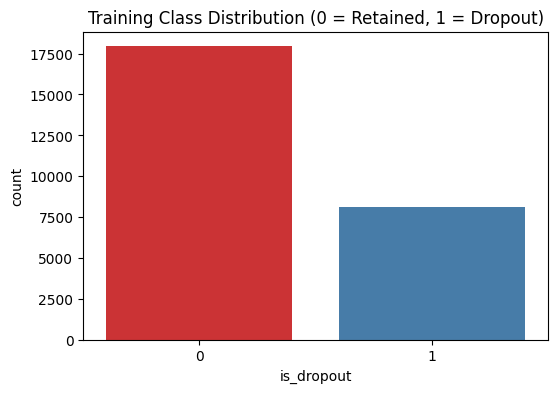

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, palette='Set1')
plt.title('Training Class Distribution (0 = Retained, 1 = Dropout)')
plt.show()

In [6]:
missing_cols = X_train.isnull().sum()
print(missing_cols[missing_cols > 0])

X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

date_registration    33
dtype: int64


Balanced Training data shape: (35898, 12)
Balanced Target distribution: Counter({0: 17949, 1: 17949})


/var/folders/b3/0fd8bgg112d1_6p01j251slr0000gn/T/ipykernel_73508/1694802184.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_balanced, palette='Set1')


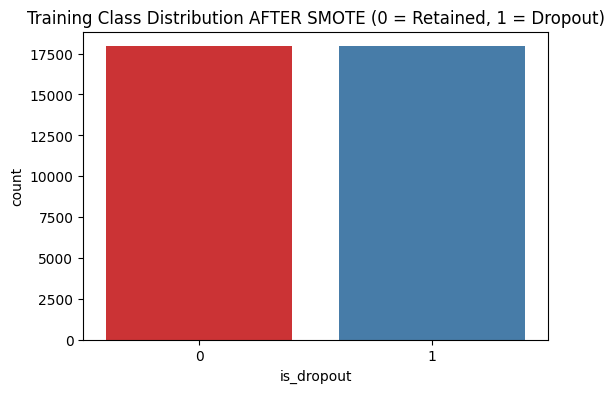

In [7]:
# 3. APPLY SMOTE (Balancing the Training Data)
smote = SMOTE(random_state=42)

# ONLY apply SMOTE to the training data. The test data must remain 
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Balanced Training data shape: {X_train_balanced.shape}")
print(f"Balanced Target distribution: {Counter(y_train_balanced)}")

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_balanced, palette='Set1')
plt.title('Training Class Distribution AFTER SMOTE (0 = Retained, 1 = Dropout)')
plt.show()

### Random Forest Classification for Safe/Risky

In [8]:
# Train the model 
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [9]:
import joblib

#  SAVE THE MODEL 
model_path = '../../models/dropout/rf_dropout_model.joblib'
joblib.dump(rf_model, model_path)
print(f"Model saved  to: {model_path}")

# 3. SAVE THE TEST DATA (Crucial for honest evaluation later)
X_test.to_csv('../../data/processed/dropout/X_test.csv', index=False)
y_test.to_csv('../../data/processed/dropout/y_test.csv', index=False)
id_test.to_csv('../../data/processed/dropout/student_ids.csv', index=False)

# Save the column names so we can map Feature Importance later
pd.Series(X_train.columns).to_csv('../../data/processed/dropout/feature_names.csv', index=False)
print("Test data and feature names exported for evaluation.")

Model saved  to: ../../models/dropout/rf_dropout_model.joblib
Test data and feature names exported for evaluation.
